In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

crime_df_2026 = pd.read_csv('../data/raw/police_calls/pd_calls_for_service_2026_datasd.csv')
crime_df_2025 = pd.read_csv('../data/raw/police_calls/pd_calls_for_service_2025_datasd.csv')
crime_df_2024 = pd.read_csv('../data/raw/police_calls/pd_calls_for_service_2024_datasd.csv')    
crime_df_2023 = pd.read_csv('../data/raw/police_calls/pd_calls_for_service_2023_datasd.csv')    


crime_df_2026 = crime_df_2026.copy()
crime_df_2025 = crime_df_2025.copy()
crime_df_2024 = crime_df_2024.copy()
crime_df_2023 = crime_df_2023.copy()

crime_df = pd.concat([crime_df_2026, crime_df_2025, crime_df_2024, crime_df_2023], ignore_index=True)



print(display(crime_df.head()))

,INCIDENT_NUM,DATE_TIME,DAY_OF_WEEK,ADDRESS_NUMBER_PRIMARY,ADDRESS_DIR_PRIMARY,ADDRESS_ROAD_PRIMARY,ADDRESS_SFX_PRIMARY,ADDRESS_DIR_INTERSECTING,ADDRESS_ROAD_INTERSECTING,ADDRESS_SFX_INTERSECTING,...,address_dir_primary,address_road_primary,address_sfx_primary,address_dir_intersecting,address_road_intersecting,address_sfx_intersecting,call_type,disposition,beat,priority
0,E26040027829,2026-04-20 10:42:20.000,2.0,200.0,NaN,C,ST,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E26040027830,2026-04-20 10:44:09.000,2.0,5500.0,NaN,ADOBE FALLS,RD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E26040027831,2026-04-20 10:44:12.000,2.0,5000.0,NaN,NEWPORT,AVE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E26040027832,2026-04-20 10:44:52.000,2.0,4000.0,NaN,04TH,AVE,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E26040027833,2026-04-20 10:45:30.000,2.0,0.0,NaN,LA CROSSE,AVE,NaN,HOPI PL,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


None


In [2]:
#  summary statistics of crime df 
print(display(crime_df.describe())) 

#  info about nulls, dtypes, and how many entries there are 
print(crime_df.info())

,DAY_OF_WEEK,ADDRESS_NUMBER_PRIMARY,ADDRESS_DIR_INTERSECTING,ADDRESS_SFX_INTERSECTING,BEAT,PRIORITY,day_of_week,address_number_primary,address_dir_intersecting,address_sfx_intersecting,beat,priority
count,1.588588e+06,1.588588e+06,0.0,0.0,1.588588e+06,1.588588e+06,463554.000000,463554.000000,0.0,0.0,463554.000000,463554.000000
mean,4.049117e+00,3.267466e+03,NaN,NaN,4.828550e+02,2.083648e+00,4.024200,3330.140566,NaN,NaN,484.461342,2.092854
std,1.961337e+00,3.368203e+03,NaN,NaN,2.362282e+02,1.127989e+00,1.939444,3375.663402,NaN,NaN,239.176131,1.162665
min,1.000000e+00,0.000000e+00,NaN,NaN,-1.000000e+00,0.000000e+00,1.000000,0.000000,NaN,NaN,-1.000000,0.000000
25%,2.000000e+00,5.000000e+02,NaN,NaN,3.130000e+02,1.000000e+00,2.000000,500.000000,NaN,NaN,313.000000,1.000000
50%,4.000000e+00,2.500000e+03,NaN,NaN,5.210000e+02,2.000000e+00,4.000000,2600.000000,NaN,NaN,521.000000,2.000000
75%,6.000000e+00,4.800000e+03,NaN,NaN,6.250000e+02,3.000000e+00,6.000000,4800.000000,NaN,NaN,626.000000,3.000000
max,7.000000e+00,2.028000e+05,NaN,NaN,9.370000e+02,9.000000e+00,7.000000,53500.000000,NaN,NaN,937.000000,9.000000


None
<class 'pandas.DataFrame'>
RangeIndex: 2052142 entries, 0 to 2052141
Data columns (total 28 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   INCIDENT_NUM               str    
 1   DATE_TIME                  str    
 2   DAY_OF_WEEK                float64
 3   ADDRESS_NUMBER_PRIMARY     float64
 4   ADDRESS_DIR_PRIMARY        str    
 5   ADDRESS_ROAD_PRIMARY       str    
 6   ADDRESS_SFX_PRIMARY        str    
 7   ADDRESS_DIR_INTERSECTING   float64
 8   ADDRESS_ROAD_INTERSECTING  str    
 9   ADDRESS_SFX_INTERSECTING   float64
 10  CALL_TYPE                  str    
 11  DISPOSITION                str    
 12  BEAT                       float64
 13  PRIORITY                   float64
 14  incident_num               str    
 15  date_time                  str    
 16  day_of_week                float64
 17  address_number_primary     float64
 18  address_dir_primary        str    
 19  address_road_primary       str    
 20  address_

## Crime dataset — columns overview

| Column | Keep? | Why |
|---|---|---|
| `INCIDENT_NUM` | Yes | Unique identifier for each incident |
| `DATE_TIME` | Yes | Used to parse time of day and filter by year |
| `DAY_OF_WEEK` | Yes | Useful for understanding when incidents happen (day vs night) |
| `ADDRESS_NUMBER_PRIMARY` | Yes | House number — needed to build the full geocodable address |
| `ADDRESS_DIR_PRIMARY` | Yes | Street direction (N, S, E, W) — part of the full address |
| `ADDRESS_ROAD_PRIMARY` | Yes | Street name — needed for geocoding incidents to coordinates |
| `ADDRESS_SFX_PRIMARY` | Yes | Street suffix (St, Ave, Blvd) — part of the full address |
| `CALL_TYPE` | Yes | Type of incident — we filter this down to pedestrian-relevant crimes only |
| `DISPOSITION` | Yes | How the call was resolved — helps filter out false alarms and unfounded calls |
| `BEAT` | Yes | Police beat zone — kept through filtering, dropped before final save |
| `PRIORITY` | Yes | Severity of the call — higher priority incidents weighted more in safety score |
| `ADDRESS_ROAD_INTERSECTING` | No | Intersecting street — not useful for scoring |
| `ADDRESS_DIR_INTERSECTING` | No | Completely empty column |
| `ADDRESS_SFX_INTERSECTING` | No | Completely empty column |

In [3]:
cols_to_keep = [
    'INCIDENT_NUM',
    'DATE_TIME',
    'DAY_OF_WEEK',
    'ADDRESS_NUMBER_PRIMARY',
    'ADDRESS_DIR_PRIMARY',
    'ADDRESS_ROAD_PRIMARY',
    'ADDRESS_SFX_PRIMARY',
    'CALL_TYPE',
    'DISPOSITION',
    'BEAT',
    'PRIORITY'
]
crime_df = crime_df[cols_to_keep]
print(display(crime_df.head()))

# check for nulls
print(crime_df.isnull().sum())
"""
Dir_primary and SFX_primary has a lot of nulls, 
however we can still use the other address fields to construct a 
full address for geocoding, so we will keep these columns for now.
Not all addresses have a direction or suffix, so we can fill these nulls with empty strings.
"""
# num of rows
print(f"There are {len(crime_df)} rows in the DataFrame.")

,INCIDENT_NUM,DATE_TIME,DAY_OF_WEEK,ADDRESS_NUMBER_PRIMARY,ADDRESS_DIR_PRIMARY,ADDRESS_ROAD_PRIMARY,ADDRESS_SFX_PRIMARY,CALL_TYPE,DISPOSITION,BEAT,PRIORITY
0,E26040027829,2026-04-20 10:42:20.000,2.0,200.0,NaN,C,ST,5150,K,524.0,2.0
1,E26040027830,2026-04-20 10:44:09.000,2.0,5500.0,NaN,ADOBE FALLS,RD,10851R,R,323.0,2.0
2,E26040027831,2026-04-20 10:44:12.000,2.0,5000.0,NaN,NEWPORT,AVE,1151,K,614.0,2.0
3,E26040027832,2026-04-20 10:44:52.000,2.0,4000.0,NaN,04TH,AVE,MTG,K,627.0,4.0
4,E26040027833,2026-04-20 10:45:30.000,2.0,0.0,NaN,LA CROSSE,AVE,INFOT,W,113.0,2.0


None
INCIDENT_NUM               463554
DATE_TIME                  463554
DAY_OF_WEEK                463554
ADDRESS_NUMBER_PRIMARY     463554
ADDRESS_DIR_PRIMARY       1982496
ADDRESS_ROAD_PRIMARY       470183
ADDRESS_SFX_PRIMARY        612207
CALL_TYPE                  466532
DISPOSITION                469516
BEAT                       463554
PRIORITY                   463554
dtype: int64
There are 2052142 rows in the DataFrame.


In [4]:
# Summary stats of numerical columns
print(display(crime_df.describe()))

# Summary stats of categorical columns
for i in crime_df.columns:
    if crime_df[i].dtype != 'int64' and crime_df[i].dtype != 'float64':
        print(f"Value counts for {i}:")
        print(crime_df[i].nunique()) # count unique vals for each
        print("\n")



,DAY_OF_WEEK,ADDRESS_NUMBER_PRIMARY,BEAT,PRIORITY
count,1.588588e+06,1.588588e+06,1.588588e+06,1.588588e+06
mean,4.049117e+00,3.267466e+03,4.828550e+02,2.083648e+00
std,1.961337e+00,3.368203e+03,2.362282e+02,1.127989e+00
min,1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00
25%,2.000000e+00,5.000000e+02,3.130000e+02,1.000000e+00
50%,4.000000e+00,2.500000e+03,5.210000e+02,2.000000e+00
75%,6.000000e+00,4.800000e+03,6.250000e+02,3.000000e+00
max,7.000000e+00,2.028000e+05,9.370000e+02,9.000000e+00


None
Value counts for INCIDENT_NUM:
1091039


Value counts for DATE_TIME:
1081980


Value counts for ADDRESS_DIR_PRIMARY:
10


Value counts for ADDRESS_ROAD_PRIMARY:
11793


Value counts for ADDRESS_SFX_PRIMARY:
39


Value counts for CALL_TYPE:
256


Value counts for DISPOSITION:
21




In [5]:
# Print the unique values of CALL_TYPE and DISPOSITION
print("Unique CALL_TYPE values:")
print(crime_df['CALL_TYPE'].unique())

print("\nUnique DISPOSITION values:")
print(crime_df['DISPOSITION'].unique())

Unique CALL_TYPE values:
<ArrowStringArray>
[    '5150',   '10851R',     '1151',      'MTG',    'INFOT',      'AU2',
     '1185',    '415PP',       'CW',      '911',
 ...
      '247',   'LPR-MP',    'SCALP',   'ALERT2',    'FLOCK',    '1016P',
 'PARTY-CR',  'CCF-RRM',    '470RX',  '1184-CR']
Length: 257, dtype: str

Unique DISPOSITION values:
<ArrowStringArray>
[  'K',   'R',   'W', 'CAN',   'O',   'A',   'U',   nan, 'DUP',   'S',   'X',
  'KB',   'V',  'RB', 'OHR', 'RHR', 'SS-', 'KHR',  'AB', 'DEF', '360', 'AHR']
Length: 22, dtype: str


## Crime data filtering — why we filter before anything else

### Step 1 — Filter by disposition (was this a real incident?)

The `DISPOSITION` column tells us what happened when police responded to the call.
Before we count anything as a "crime" for our safety score, we need to make sure
it actually happened. Many calls in the dataset were cancelled, duplicated, or
determined to be unfounded — including those would inflate our crime counts and
make safe areas look more dangerous than they are.

**Keep — confirmed real incidents:**

| Code | Meaning | Why we keep it |
|---|---|---|
| `A` | Arrest made | Crime confirmed, suspect apprehended |
| `AB` | Arrest made, board and secure | Same as above |
| `AHR` | Arrest made, high risk | Same as above — crisis response involved |
| `R` | Report taken | Crime confirmed, report filed |
| `RB` | Report taken, board and secure | Same as above |
| `RHR` | Report, high risk | Same as above — crisis response involved |
| `O` | Other | Officer responded and took action |
| `OHR` | Other, high risk | Same as above — crisis response involved |
| `S` | Stolen/recovered vehicle | Confirmed incident |

**Drop — not real or not actionable:**

| Code | Meaning | Why we drop it |
|---|---|---|
| `U` | Unfounded | Police determined nothing happened |
| `X` | Cancelled before unit on scene | Never verified |
| `K` | No report required | Officer arrived, nothing to act on |
| `KB` | No report required, board and secure | Same as above |
| `KHR` | No further action, high risk | Same as above |
| `CAN` | Cancelled | Call was cancelled |
| `DUP` | Duplicate | Already counted elsewhere |
| `W` | Warning issued | Minor, not a safety threat |

---

### Step 2 — Filter by call type (is this relevant to pedestrian safety?)

The `CALL_TYPE` column has 234 unique codes covering everything from violent
assaults to noise complaints to lost property. For SafePath, we only care about
incidents that would actually affect how safe it feels to walk through an area.
Counting parking violations or medical calls in our safety score would add noise
and make the scores less meaningful.

We want to keep incidents that fall into these categories:

**Keep — pedestrian safety relevant:**
- Violent crimes (assault, robbery, weapons)
- Threats and disturbances involving people
- Suspicious persons or activity
- Sexual offenses
- Incidents involving drugs or alcohol in public

**Drop — not relevant to walking safety:**
- Traffic violations and parking
- Medical/fire calls (not crime-related)
- Lost/found property
- Administrative calls (report pickups, paperwork)
- Noise complaints with no threat involved

## Call type filter — pedestrian safety relevant incidents

Source: [SDPD Call Type Codes](https://data.sandiego.gov/datasets/police-calls-call-types/)

We keep only call types that represent a direct or indirect threat to someone
walking through an area. Traffic, parking, administrative, medical, noise-only,
and internal police operations are excluded since they do not reflect personal
safety risk to a pedestrian.

| Category | Codes kept | Why |
|---|---|---|
| Homicide | `187`, `187-SUSP` | Highest severity violent crime |
| Kidnapping | `207`, `207R` | Direct threat to personal safety |
| Robbery | `211`, `211-SUSP`, `211R`, `211C` | Common pedestrian-targeted crime |
| Carjacking | `215`, `215R` | Violent crime near streets |
| Battery | `242`, `242R` | Physical assault |
| Assault w/ deadly weapon | `245`, `245-SUSP`, `245DV`, `245R` | High-severity violent crime |
| Shooting | `246`, `246R`, `247`, `247R`, `11-6`, `11-6SPT` | Dangerous to anyone nearby |
| Prowler | `11-7` | Direct threat to personal safety |
| Domestic violence | `415DV` | Active violent situation |
| Disturbing peace w/ violence/weapon | `415V`, `415W` | Active physical threat |
| Threatening w/ weapon | `417`, `417R` | Direct threat to person |
| Criminal threats | `422`, `422R` | Direct threat to person |
| Stalking | `646`, `646R` | Direct threat to person |
| Indecent exposure | `314`, `314R` | Threat to personal safety |
| Arson | `451`, `451R` | Dangerous to anyone nearby |
| Burglary in progress / hot prowl | `459`, `459-SUSP`, `459HP` | Active crime nearby |
| Trespassing | `602` | Suspicious/threatening activity |
| Narcotics | `NARC` | Safety concern in area |
| Drunk/drugs in public | `647F` | Safety concern for pedestrians |
| Vicious animal | `ANIMAL` | Physical safety threat |
| Explosion | `EXPLO` | Dangerous to anyone nearby |
| Bomb threat | `ALERT4`, `BOMB`, `BOMB-S` | Dangerous to anyone nearby |
| Hazardous condition | `HZRD`, `1155` | Physical safety threat |
| Hate crime | `HATEINV`, `AUHATE` | Targeted threat to person |
| Carrying concealed weapon | `CCW` | Threat to public safety |
| Witness intimidation | `136` | Threatening behavior |
| Foot pursuit | `FP` | Active dangerous situation |
| Escape/escapee | `ESCAPE` | Active dangerous situation |
| Mental case violent | `5150V` | Active safety threat |

In [6]:
# Filter out rows with only the important CALL_TYPEs and DISPOSITIONs

important_disposition = ['A','AB','AHR', 'R', 'RB', 'RHR', 'O', 'OHR', 'S']
pedestrian_call_types = [
    # Violent crimes
    '187', '187-SUSP',
    '207', '207R',
    '211', '211-SUSP', '211R', '211C',
    '215', '215R',
    '242', '242R',
    '245', '245-SUSP', '245DV', '245R',
    '246', '246R', '247', '247R',
    '11-6', '11-6SPT', '11-7',
    # Threats and disturbances
    '415DV', '415V', '415W',
    '417', '417R',
    '422', '422R',
    '646', '646R',
    '314', '314R',
    '136', '653M',
    # Active crimes nearby
    '451', '451R',
    '459', '459-SUSP', '459HP',
    '602',
    # Area safety concerns
    'NARC', '647F',
    'ANIMAL',
    'EXPLO', 'ALERT4', 'BOMB', 'BOMB-S',
    'HZRD', '1155',
    'HATEINV', 'AUHATE',
    'CCW',
    'FP', 'ESCAPE',
    '5150V',
]

crime_df_filtered = crime_df[crime_df['CALL_TYPE'].isin(pedestrian_call_types)]
crime_df_filtered = crime_df_filtered[crime_df_filtered['DISPOSITION'].isin(important_disposition)]
print(f"Rows Remaining before filter: {len(crime_df)}")
print(f"Rows remaining after filter: {len(crime_df_filtered)}")



Rows Remaining before filter: 2052142
Rows remaining after filter: 46600


In [7]:
# check nulls again after filtering
print(crime_df_filtered.info())
"""
In filtered df, we still have nulls in the address
but we can still use the other address fields to construct a full address
especially with primary number having no nulls and road primary having only 1 null 
which means for most of the data we can construct a full address for geocoding, 
and for the few that are missing Dir_primary or SFX_primary, we can just fill 
those with empty strings since not all addresses have a direction or suffix.
"""
crime_df_filtered = crime_df_filtered[~crime_df_filtered['ADDRESS_ROAD_PRIMARY'].isnull()]
print(crime_df_filtered.info())


<class 'pandas.DataFrame'>
Index: 46600 entries, 13 to 1588500
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   INCIDENT_NUM            46600 non-null  str    
 1   DATE_TIME               46600 non-null  str    
 2   DAY_OF_WEEK             46600 non-null  float64
 3   ADDRESS_NUMBER_PRIMARY  46600 non-null  float64
 4   ADDRESS_DIR_PRIMARY     1929 non-null   str    
 5   ADDRESS_ROAD_PRIMARY    46444 non-null  str    
 6   ADDRESS_SFX_PRIMARY     43308 non-null  str    
 7   CALL_TYPE               46600 non-null  str    
 8   DISPOSITION             46600 non-null  str    
 9   BEAT                    46600 non-null  float64
 10  PRIORITY                46600 non-null  float64
dtypes: float64(4), str(7)
memory usage: 6.5 MB
None
<class 'pandas.DataFrame'>
Index: 46444 entries, 13 to 1588500
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------  

In [8]:
# removed rows with nulls in ADDRESS_ROAD_PRIMARY since we can't geocode without a road name

print(crime_df_filtered.info())


<class 'pandas.DataFrame'>
Index: 46444 entries, 13 to 1588500
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   INCIDENT_NUM            46444 non-null  str    
 1   DATE_TIME               46444 non-null  str    
 2   DAY_OF_WEEK             46444 non-null  float64
 3   ADDRESS_NUMBER_PRIMARY  46444 non-null  float64
 4   ADDRESS_DIR_PRIMARY     1929 non-null   str    
 5   ADDRESS_ROAD_PRIMARY    46444 non-null  str    
 6   ADDRESS_SFX_PRIMARY     43308 non-null  str    
 7   CALL_TYPE               46444 non-null  str    
 8   DISPOSITION             46444 non-null  str    
 9   BEAT                    46444 non-null  float64
 10  PRIORITY                46444 non-null  float64
dtypes: float64(4), str(7)
memory usage: 6.5 MB
None


In [9]:
# feature engineer columns dealing with time and date
# we do this so we can filter out crimes by time of day

crime_df_filtered['DATE_TIME'] = pd.to_datetime(crime_df_filtered['DATE_TIME'], errors='coerce')

crime_df_filtered['HOUR'] = crime_df_filtered['DATE_TIME'].dt.hour


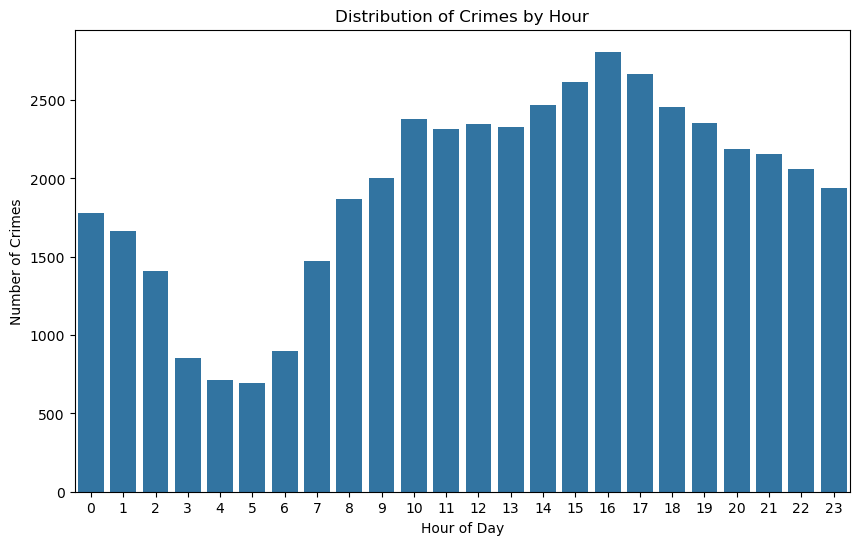

In [10]:
# check distribution of crimes by hour 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x='HOUR', data=crime_df_filtered)
plt.title('Distribution of Crimes by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Crimes')
plt.xticks(range(0, 24))
plt.show()



In [11]:
# check Top 10 most common Call Types
print(crime_df_filtered['CALL_TYPE'].value_counts().head(10))

CALL_TYPE
415V     8815
242      5253
245      3716
5150V    3383
417      3348
242R     2962
HZRD     2939
211      2671
459      1708
602      1396
Name: count, dtype: int64


## Crime data — post-filter EDA

### Top 10 call types after filtering

| Call type | Description | Count |
|---|---|---|
| `415V` | Disturbing peace with violence | 894 |
| `242` | Battery | 489 |
| `5150V` | Mental case — violent or urgent | 338 |
| `HZRD` | Hazardous condition | 333 |
| `417` | Threatening with weapon | 317 |
| `245` | ADW (assault with deadly weapon) | 303 |
| `242R` | Battery report | 296 |
| `211` | Robbery | 241 |
| `602` | Trespassing | 163 |
| `459` | Burglary in progress | 140 |

### Key observations

- `415V` dominates at 894 incidents — disturbing peace with violence is the most
  common pedestrian-relevant crime in San Diego, reflecting active confrontational
  situations a walker would want to avoid
- Battery (`242` + `242R`) totals 785 combined — the most common confirmed physical
  assault type across both in-progress and report versions
- `5150V` (violent mental health crisis) at 338 reflects San Diego's homeless
  population concentrated in specific beats — expect clear geographic clusters in scoring
- Serious violent crimes (`211` robbery, `245` ADW, `417` threatening with weapon)
  are well represented — these will carry heavier weights in the Week 3 scoring algorithm
- Distribution confirms our call type filter is working correctly — no noise complaints,
  parking, or administrative calls remain

DISPOSITION
R      21987
A      16163
O       8268
AB        11
S          9
OHR        3
AHR        2
RB         1
Name: count, dtype: int64


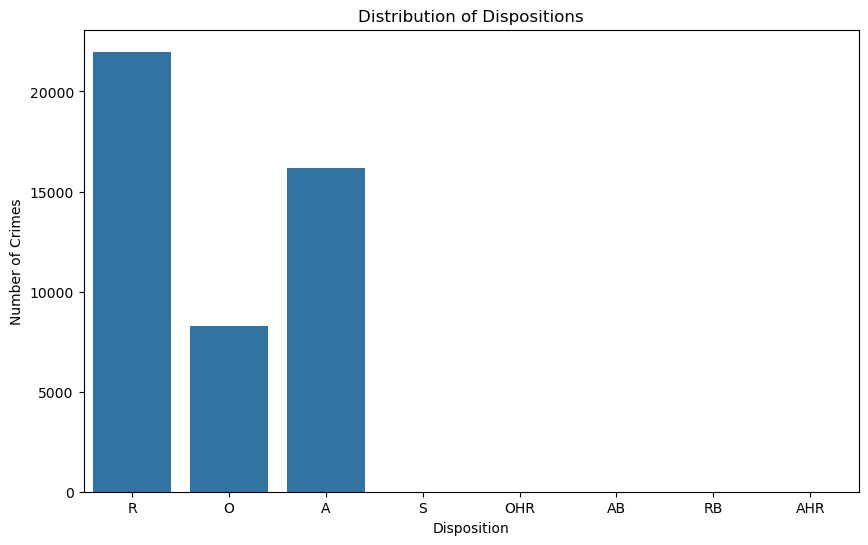

In [12]:
# Chheck distribution of Dispositions
print(crime_df_filtered['DISPOSITION'].value_counts())

fig = plt.figure(figsize=(10, 6))
sns.countplot(x='DISPOSITION', data=crime_df_filtered)
plt.title('Distribution of Dispositions')
plt.xlabel('Disposition')
plt.ylabel('Number of Crimes')
plt.show()

## Crime data — disposition distribution after filtering

| Disposition | Description | Count |
|---|---|---|
| `R` | Report taken | 1965 |
| `A` | Arrest made | 1566 |
| `O` | Other | 897 |
| `OHR` | Other, high risk (crisis response team) | 2 |
| `S` | Stolen/recovered vehicle | 1 |
| `AB` | Arrest made, board and secure | 1 |

### Key observations

- `R` (report taken) and `A` (arrest made) make up the vast majority at 3,531 combined —
  these are the strongest confirmed incidents and form the backbone of our crime scoring
- `O` (other) at 897 means an officer responded and took action but the outcome didn't
  fit a standard category — still a valid confirmed incident worth keeping
- `OHR`, `S`, and `AB` are negligible in count but represent real high-severity incidents
  so we keep them
- No cancelled, unfounded, or duplicate dispositions remain — the filter worked correctly

## Geocoding — building point geometry from addresses

Nominatim (OpenStreetMap) geocodes each unique filtered address to exact lat/lon coordinates.

`fix_address` normalizes addresses before geocoding: zero-padded ordinal streets (`04TH` → `4th`) and common suffix abbreviations (`BLV` → `Blvd`, `AVE` → `Ave`) are cleaned to improve Nominatim match rates.

Results are cached to `geocode_cache.json` so the geocoding loop is resumable after interruption. The cache is automatically migrated to use cleaned address keys on each run.

In [21]:
import json, os, re

def fix_address(address):
    # fix zero-padded ordinal streets: 04TH → 4th, 08TH → 8th
    address = re.sub(r'\b0?(\d+)TH\b', lambda m: m.group(1) + 'th', address)
    address = re.sub(r'\b0?(\d+)ST\b', lambda m: m.group(1) + 'st', address)
    address = re.sub(r'\b0?(\d+)ND\b', lambda m: m.group(1) + 'nd', address)
    address = re.sub(r'\b0?(\d+)RD\b', lambda m: m.group(1) + 'rd', address)

    abbrev_fixes = {
        r'\bBLV\b': 'Blvd',  r'\bBLVD\b': 'Blvd',
        r'\bAVE\b': 'Ave',   r'\bST\b':   'St',
        r'\bDR\b':  'Dr',    r'\bRD\b':   'Rd',
        r'\bLN\b':  'Ln',    r'\bCT\b':   'Ct',
        r'\bPL\b':  'Pl',    r'\bWAY\b':  'Way',
        r'\bHWY\b': 'Hwy',   r'\bFWY\b':  'Freeway',
        r'\bPKW\b': 'Pkwy',  r'\bWAL\b':  'Walk',
        r'\(NB\)': '', r'\(SB\)': '', r'\(EB\)': '', r'\(WB\)': '',
    }

    for pattern, replacement in abbrev_fixes.items():
        address = re.sub(pattern, replacement, address)
    return re.sub(r'\s+', ' ', address).strip()

crime_geocode_df = crime_df_filtered.copy()

# ADDRESS_NUMBER_PRIMARY is stored as float (e.g. 4300.0).
# astype(str) would produce "4300.0" — Nominatim cannot resolve a decimal house number.
# Convert to int first so the address reads "4300 LANDIS St", not "4300.0 LANDIS St".
def fmt_number(x):
    try:
        return str(int(float(x)))
    except (ValueError, TypeError):
        return ''

crime_geocode_df['full_address'] = (
    crime_geocode_df['ADDRESS_NUMBER_PRIMARY'].apply(fmt_number) + ' ' +
    crime_geocode_df['ADDRESS_DIR_PRIMARY'].fillna('') + ' ' +
    crime_geocode_df['ADDRESS_ROAD_PRIMARY'].fillna('') + ' ' +
    crime_geocode_df['ADDRESS_SFX_PRIMARY'].fillna('') +
    ', San Diego, CA'
).str.replace(r'\s+', ' ', regex=True).str.strip()

crime_geocode_df['full_address'] = crime_geocode_df['full_address'].apply(fix_address)

total = len(crime_geocode_df)
missing_road  = crime_geocode_df['ADDRESS_ROAD_PRIMARY'].isna().sum()
zero_number = (crime_geocode_df['ADDRESS_NUMBER_PRIMARY'] == 0).sum()
missing_suffix = crime_geocode_df['ADDRESS_SFX_PRIMARY'].isna().sum()
print(f"Total rows:             {total}")
print(f"Missing road name:      {missing_road} ({missing_road / total * 100:.1f}%)")
print(f"Address number is 0:    {zero_number} ({zero_number / total * 100:.1f}%)")
print(f"Missing street suffix:  {missing_suffix} ({missing_suffix / total * 100:.1f}%)")
print(f"\nSample full_address values:")
print(crime_geocode_df['full_address'].head(10).to_string())


Total rows:             46444
Missing road name:      0 (0.0%)
Address number is 0:    7585 (16.3%)
Missing street suffix:  3136 (6.8%)

Sample full_address values:
13           6100 EL CAJON Blvd, San Diego, CA
42                     500 C St, San Diego, CA
48     1600 HOTEL CIRCLE SOUTH , San Diego, CA
56               4300 LANDIS St, San Diego, CA
219                4600 AIR Way, San Diego, CA
229                1200 4th Ave, San Diego, CA
301         4100 UNIVERSITY Ave, San Diego, CA
315     14800 WAVERLY DOWNS Way, San Diego, CA
336              900 CARDIFF St, San Diego, CA
337              3800 SWIFT Ave, San Diego, CA


In [25]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

geolocator = Nominatim(user_agent='safepath_geocoder_v1')
geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, error_wait_seconds=5, max_retries=2)

CACHE_PATH = '../data/processed/geocode_cache.json'
cache = {}
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        raw_cache = json.load(f)
    # Migrate keys through fix_address so lookups hit correctly.
    # Drop None-result entries — they may have failed due to the "4300.0" float bug
    # and will be retried with corrected addresses.
    cache = {}
    for k, v in raw_cache.items():
        cleaned = fix_address(k)
        if v.get('lat') is not None:          # keep only successful geocodes
            cache[cleaned] = v
        elif cleaned == k:                     # keep None result only if key is unchanged
            cache[cleaned] = v
    with open(CACHE_PATH, 'w') as f:
        json.dump(cache, f)
    print(f"Loaded cache: {len(cache)} successful entries (None-results dropped for retry)")

unique_addresses = crime_geocode_df['full_address'].unique()
remaining = [a for a in unique_addresses if a not in cache]
print(f"Unique addresses:  {len(unique_addresses)}")
print(f"Already cached:    {len(unique_addresses) - len(remaining)}")
print(f"To geocode:        {len(remaining)}")


Loaded cache: 18346 successful entries (None-results dropped for retry)
Unique addresses:  9303
Already cached:    9043
To geocode:        260


In [26]:
for i, address in enumerate(remaining): # geocode remaining addresses that aren't in cache
    try:
        # geocodes the address and stores result in cache, if fails store None for lat and lon
        location = geocode(address)
        cache[address] = (
            {'lat': location.latitude, 'lon': location.longitude}
            if location else {'lat': None, 'lon': None}
        )
    except Exception:
        cache[address] = {'lat': None, 'lon': None}
    # sees results every 50 geocodes and saves to cache in case of errors or interruptions
    if (i + 1) % 50 == 0:
        with open(CACHE_PATH, 'w') as f:
            json.dump(cache, f)
        print(f"  {i + 1}/{len(remaining)} geocoded, cache saved")
# final save after geocoding is completed 
with open(CACHE_PATH, 'w') as f:
    json.dump(cache, f)
print(f"Geocoding complete — {len(remaining)} addresses processed, cache saved to {CACHE_PATH}")

  50/260 geocoded, cache saved
  100/260 geocoded, cache saved
  150/260 geocoded, cache saved
  200/260 geocoded, cache saved
  250/260 geocoded, cache saved
Geocoding complete — 260 addresses processed, cache saved to ../data/processed/geocode_cache.json


In [27]:
crime_geocode_df['lat'] = crime_geocode_df['full_address'].map(lambda x: cache.get(x, {}).get('lat'))
crime_geocode_df['lon'] = crime_geocode_df['full_address'].map(lambda x: cache.get(x, {}).get('lon'))

success = crime_geocode_df[['lat', 'lon']].notna().all(axis=1).sum()
failed  = len(crime_geocode_df) - success
print(f"Successfully geocoded: {success} ({success / len(crime_geocode_df) * 100:.1f}%)")
print(f"Failed to geocode:     {failed}  ({failed  / len(crime_geocode_df) * 100:.1f}%)")
if failed > 0:
    print("\nSample failed addresses:")
    print(crime_geocode_df[crime_geocode_df['lat'].isna()]['full_address'].head(10).to_string())

Successfully geocoded: 45742 (98.5%)
Failed to geocode:     702  (1.5%)

Sample failed addresses:
2410     12000 SCRIPPS HIGHLANDS Dr, San Diego, CA
3296               1700 KEARNEY Ave, San Diego, CA
7010         1200 PASEO SEA BREEZE , San Diego, CA
7343       13500 SABRE SPRINGS Pkwy, San Diego, CA
13850           11700 WESTVIEW Pkwy, San Diego, CA
16399               1300 COAST Walk, San Diego, CA
16924         2500 OCEAN FRONT Walk, San Diego, CA
17159                     0 NB 805 , San Diego, CA
19627        0 E SAN YSIDRO Blvd E , San Diego, CA
20813            3000 CHILDRENS Way, San Diego, CA


In [28]:
crime_geocoded_gdf = crime_geocode_df.dropna(subset=['lat', 'lon']).copy()
crime_geocoded_gdf = crime_geocoded_gdf.drop(columns=[
    'ADDRESS_NUMBER_PRIMARY', 'ADDRESS_DIR_PRIMARY', 'ADDRESS_SFX_PRIMARY', 'full_address', 'BEAT'
])
crime_final_gdf = gpd.GeoDataFrame(
    crime_geocoded_gdf,
    geometry=gpd.points_from_xy(crime_geocoded_gdf['lon'], crime_geocoded_gdf['lat']),
    crs='EPSG:4326'
)
crime_final_gdf = crime_final_gdf.drop(columns=['lat', 'lon'])
crime_final_gdf.to_file('../data/processed/crime_final_gdf.gpkg', driver='GPKG')
print(f"Saved {len(crime_final_gdf)} rows to crime_final_gdf.gpkg")
print(crime_final_gdf.shape)
print(crime_final_gdf.crs)

Saved 45742 rows to crime_final_gdf.gpkg
(45742, 9)
EPSG:4326
